# Модель предсказания оттока клиентов

## Описание проекта

Оператор связи «ТелеДом» теряет клиентов и хочет удерживать их адресно:
предлагать промокоды и спецусловия тем, кто действительно собирается уйти,
а не всей базе подряд. Для этого нужна модель, оценивающая вероятность
расторжения договора по персональным данным, тарифу и набору услуг.

**Целевая метрика:** ROC-AUC. Дополнительно смотрим accuracy, матрицу
ошибок и важность признаков — они нужны, чтобы понять, кого модель
относит в группу риска и почему.

**План работы:**
1. Выгрузить четыре таблицы из SQLite и объединить их SQL-запросом
2. Предобработка, конструирование целевого признака из даты окончания договора
3. Разделить данные на train/test и дальше работать с train, чтобы не заглядывать в test
4. Исследование признаков и корреляционный анализ
5. Сравнение моделей с подбором гиперпараметров на кросс-валидации
6. Проверка лучшей модели на тесте, подбор порога и важность признаков

## Описание данных

Данные хранятся в SQLite — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

- `contract` — информация о договорах;
- `personal` — персональные данные клиентов;
- `internet` — информация об интернет-услугах;
- `phone` — информация об услугах телефонии.

Таблица `contract`:
- `customerID` — ID абонента;
- `BeginDate` — дата начала действия договора;
- `EndDate` — дата окончания действия договора;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента.

Таблица `personal`:
- `customerID` — ID пользователя;
- `gender` — пол;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети.

Таблица `internet`:
- `customerID` — ID пользователя;
- `InternetService` — тип подключения;
- `OnlineSecurity` — блокировка опасных сайтов;
- `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
- `DeviceProtection` — антивирус;
- `TechSupport` — выделенная линия технической поддержки;
- `StreamingTV` — стриминговое телевидение;
- `StreamingMovies` — каталог фильмов.

Таблица `phone`:
- `customerID` — ID пользователя (в таблице записан как `CustomerId`);
- `MultipleLines` — подключение телефона к нескольким линиям одновременно.

Информация о договорах актуальна на 1 февраля 2020.

## Подготовка к проекту

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
import seaborn as sns
import phik

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

### Константы

In [2]:
RANDOM_STATE = 11225

Подключение к базе данных. Проверяем реальным запросом, а не самим фактом создания `Engine` — он ленивый и ничего не открывает, пока к нему не обратились.

In [3]:
db_filename = 'data/ds-plus-final.db'
engine = create_engine(f'sqlite:///{db_filename}')

try:
    with engine.connect() as conn:
        pass
    print("Подключение к базе данных установлено.")
except Exception as e:
    print(f"Не удалось подключиться к базе данных: {e}")

Подключение к базе данных установлено.


## Загрузка данных и первичное ознакомление

Напишем функцию для ознакомления с данными и посмотрим на каждую таблицу отдельно, прежде чем объединять.

In [4]:
def inspect_table(df):
    print(f"Размер: {df.shape}")
    print('=' * 100)
    print("\nПервые 5 строк")
    display(df.head(5))
    print('=' * 100)
    print("\nИнформация о типах и пропусках")
    display(df.info())
    print('=' * 100)
    print("\nКоличество полных дубликатов строк")
    display(df.duplicated().sum())

### `contract`

In [5]:
inspect_table(pd.read_sql("SELECT * FROM contract", con=engine))

Размер: (7043, 8)

Первые 5 строк


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5



Информация о типах и пропусках
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   str  
 1   BeginDate         7043 non-null   str  
 2   EndDate           7043 non-null   str  
 3   Type              7043 non-null   str  
 4   PaperlessBilling  7043 non-null   str  
 5   PaymentMethod     7043 non-null   str  
 6   MonthlyCharges    7043 non-null   str  
 7   TotalCharges      7043 non-null   str  
dtypes: str(8)
memory usage: 440.3 KB


None


Количество полных дубликатов строк


np.int64(0)

### `personal`

In [6]:
inspect_table(pd.read_sql("SELECT * FROM personal", con=engine))

Размер: (7043, 5)

Первые 5 строк


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No



Информация о типах и пропусках
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   str  
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: str(5)
memory usage: 275.2 KB


None


Количество полных дубликатов строк


np.int64(0)

### `internet`

In [7]:
inspect_table(pd.read_sql("SELECT * FROM internet", con=engine))

Размер: (5517, 8)

Первые 5 строк


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No



Информация о типах и пропусках
<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 344.9 KB


None


Количество полных дубликатов строк


np.int64(0)

### `phone`

In [8]:
inspect_table(pd.read_sql("SELECT * FROM phone", con=engine))

Размер: (6361, 2)

Первые 5 строк


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes



Информация о типах и пропусках
<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerId     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 99.5 KB


None


Количество полных дубликатов строк


np.int64(0)

### Вывод

- Данные соответствуют описанию, явных дубликатов нет.
- Типы данных в `contract` некорректны: даты и суммы приходят строками.
- Таблица `internet` короче остальных (5517 из 7043) — часть абонентов не пользуется интернетом, это не пропуски, а отсутствие услуги. Аналогично `phone` (6361 из 7043).
- В `phone` колонка называется `CustomerId`, а не `customerID`, как в остальных таблицах.

## Объединение таблиц

Объединим все четыре таблицы одним SQL-запросом с `LEFT JOIN` по идентификатору
клиента, а не последовательными `pandas.merge` — так объединение делают в проде,
и не нужно по очереди тащить в память каждую таблицу отдельно.

In [9]:
df = pd.read_sql("""
    SELECT c.customerID, c.BeginDate, c.EndDate, c.Type, c.PaperlessBilling,
           c.PaymentMethod, c.MonthlyCharges, c.TotalCharges,
           p.gender, p.SeniorCitizen, p.Partner, p.Dependents,
           i.InternetService, i.OnlineSecurity, i.OnlineBackup, i.DeviceProtection,
           i.TechSupport, i.StreamingTV, i.StreamingMovies,
           ph.MultipleLines
    FROM contract c
    LEFT JOIN personal p ON c.customerID = p.customerID
    LEFT JOIN internet i ON c.customerID = i.customerID
    LEFT JOIN phone ph ON c.customerID = ph.CustomerId
""", con=engine)

df.shape

(7043, 20)

## Предобработка

Исправим типы данных: даты — в `datetime`, суммы — в числовой тип.

In [10]:
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
df['EndDate'] = pd.to_datetime(df['EndDate'], format='mixed', errors='coerce')

df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

`EndDate` пуст, если абонент ещё активен — это ожидаемо. А вот пропуски в `TotalCharges` неожиданны, разберёмся отдельно.

In [11]:
df[df['TotalCharges'].isnull()][['customerID', 'BeginDate', 'MonthlyCharges', 'TotalCharges']]

,customerID,BeginDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,52.55,NaN
753,3115-CZMZD,2020-02-01,20.25,NaN
936,5709-LVOEQ,2020-02-01,80.85,NaN
1082,4367-NUYAO,2020-02-01,25.75,NaN
1340,1371-DWPAZ,2020-02-01,56.05,NaN
3331,7644-OMVMY,2020-02-01,19.85,NaN
3826,3213-VVOLG,2020-02-01,25.35,NaN
4380,2520-SGTTA,2020-02-01,20.00,NaN
5218,2923-ARZLG,2020-02-01,19.70,NaN
6670,4075-WKNIU,2020-02-01,73.35,NaN


Все они начали обслуживание в один день — последний в наборе данных, то есть ещё не внесли ни одного платежа. Заполним `TotalCharges` их же `MonthlyCharges`.

In [12]:
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = \
    df.loc[df['TotalCharges'].isnull(), 'MonthlyCharges']

`SeniorCitizen` булев, но в виде 1/0 — приведём к общему формату Yes/No, как остальные признаки.

In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({'1': 'Yes', '0': 'No'})

Заполним отсутствующие услуги: пропуск здесь означает не «неизвестно», а «услугой не пользуется».

In [14]:
internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    df[col] = df[col].fillna('No')

df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

In [15]:
inspect_table(df)

Размер: (7043, 20)

Первые 5 строк


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,Female,No,Yes,No,DSL,No,Yes,No,No,No,No,No phone service
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,Male,No,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,Male,No,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,Male,No,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,Female,No,No,No,Fiber optic,No,No,No,No,No,No,No



Информация о типах и пропусках
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   str           
 1   BeginDate         7043 non-null   datetime64[us]
 2   EndDate           1101 non-null   datetime64[us]
 3   Type              7043 non-null   str           
 4   PaperlessBilling  7043 non-null   str           
 5   PaymentMethod     7043 non-null   str           
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   str           
 9   SeniorCitizen     7043 non-null   str           
 10  Partner           7043 non-null   str           
 11  Dependents        7043 non-null   str           
 12  InternetService   7043 non-null   str           
 13  OnlineSecurity    7043 non-null   str           
 14  Onl

None


Количество полных дубликатов строк


np.int64(0)

## Целевая переменная

Клиент считается ушедшим, если у его договора есть дата окончания. Целевая переменная —
`churn`: 1, если абонент расторг договор, 0, если продолжает обслуживаться. Называем
её явно `churn`, а не, скажем, `is_active`, чтобы не перепутать знак при интерпретации
метрик и матрицы ошибок дальше.

In [16]:
df['churn'] = df['EndDate'].notna().astype(int)

In [17]:
df['churn'].value_counts(normalize=True)

churn
0    0.843675
1    0.156325
Name: proportion, dtype: float64

Дисбаланс классов примерно 5.4:1 — на удержание идёт меньшинство абонентов, это стоит учесть при обучении моделей (например, `class_weight='balanced'`).

## Конструирование признаков

Изначально длительность обслуживания считалась как разница дат: `cutoff_date - BeginDate`
(или, для ушедших, `EndDate - BeginDate`). Это утечка: `BeginDate`/`EndDate` вместе с
датой среза напрямую восстанавливают факт и момент ухода, поэтому модель не столько
предсказывает отток, сколько считывает его из признака.

Вместо дат используем то, что реально известно о клиенте в любой момент — накопленные
платежи. `TotalCharges / MonthlyCharges` даёт число оплаченных месяцев без обращения
к датам вообще:

In [18]:
df['tenure_months'] = (df['TotalCharges'] / df['MonthlyCharges']).round().clip(lower=0)

`BeginDate` и `EndDate` дальше нигде не участвуют — они нужны были только для целевого признака.

Дополнительно посчитаем количество подключённых доп. услуг — иногда агрегат нагляднее шести бинарных признаков по отдельности.

In [19]:
add_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_add_services'] = df[add_service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

## Разделение на train и test

Прежде чем анализировать корреляции и отбирать признаки, отделим тестовую выборку.
Все решения по признакам дальше принимаются по `train`, чтобы не заглядывать в test заранее.

In [20]:
feature_cols = [
    'MonthlyCharges', 'TotalCharges', 'tenure_months', 'num_add_services',
    'Type', 'PaymentMethod', 'InternetService', 'MultipleLines', 'PaperlessBilling',
    'Partner', 'Dependents', 'SeniorCitizen', 'gender',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]

X = df[feature_cols]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((5282, 19), (1761, 19))

## Анализ данных

Для категориальных признаков интересна не сама структура, а то, как она расходится между ушедшими и оставшимися клиентами.

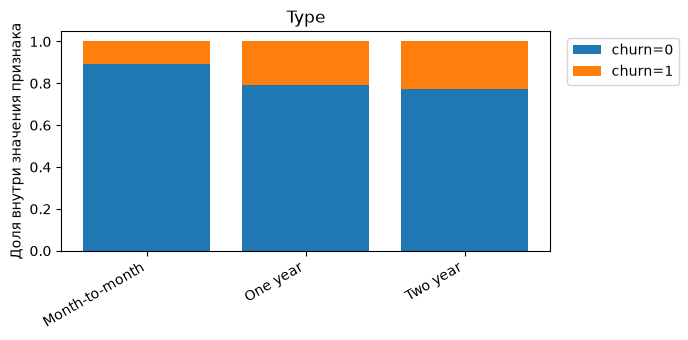

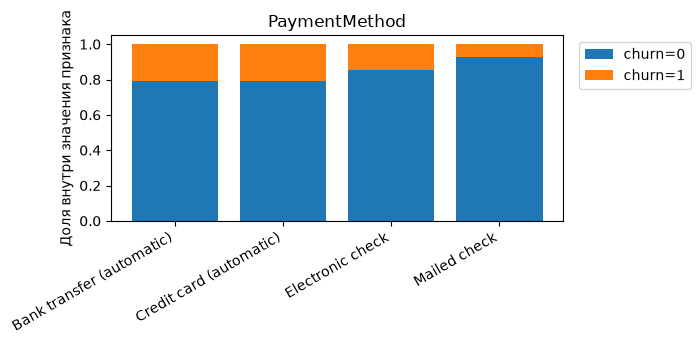

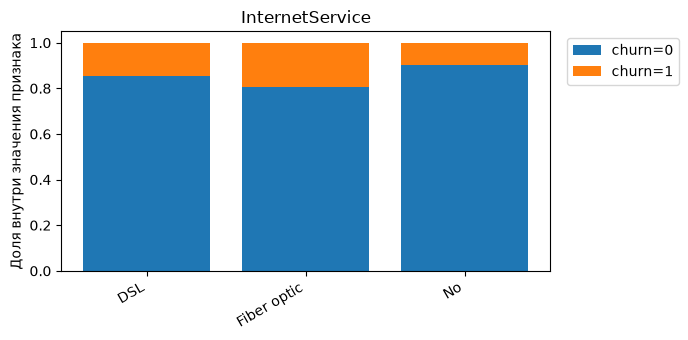

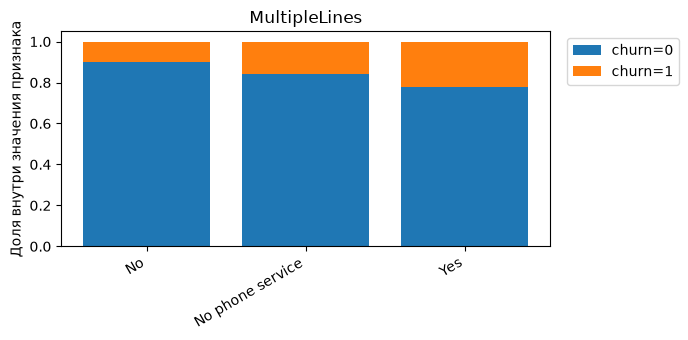

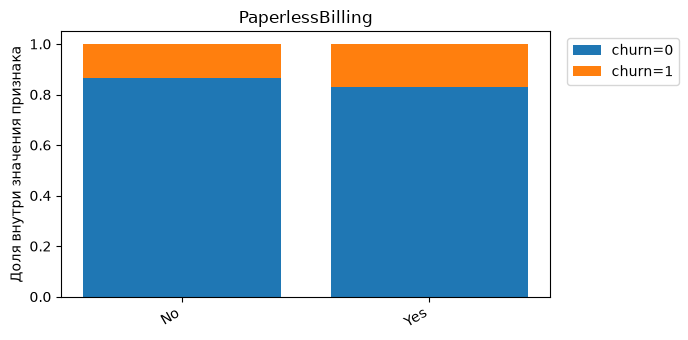

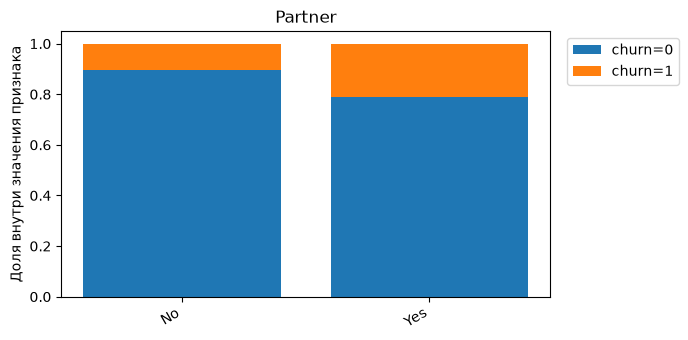

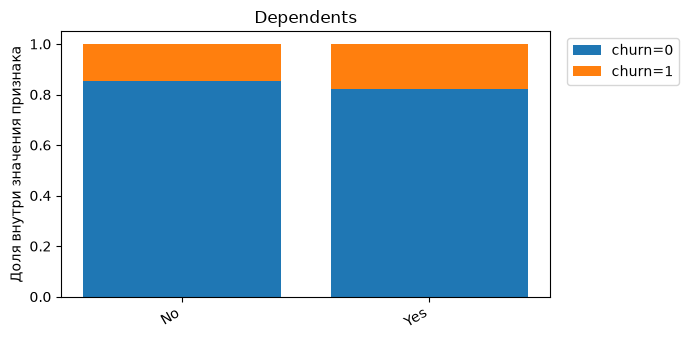

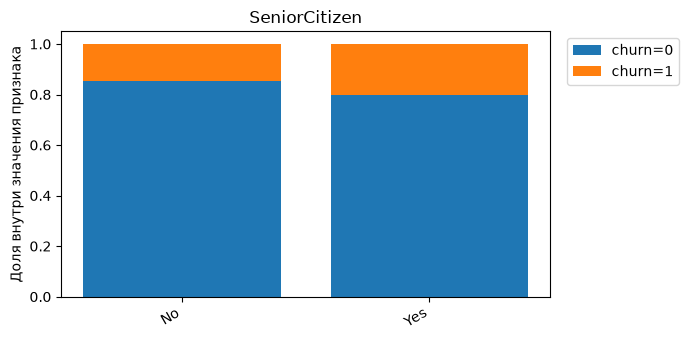

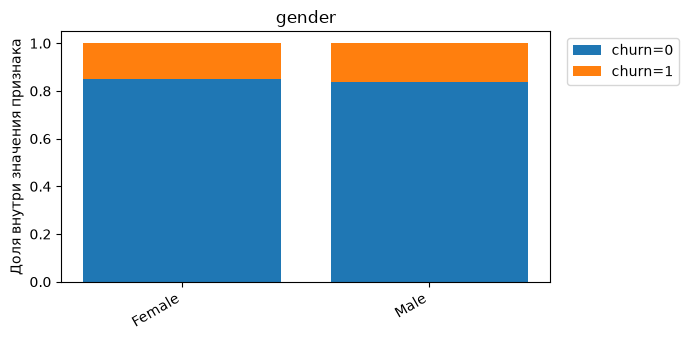

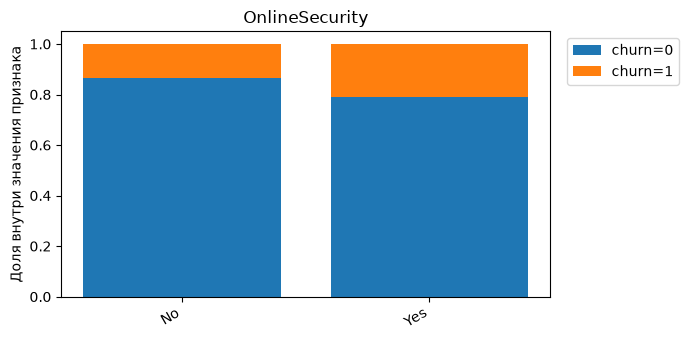

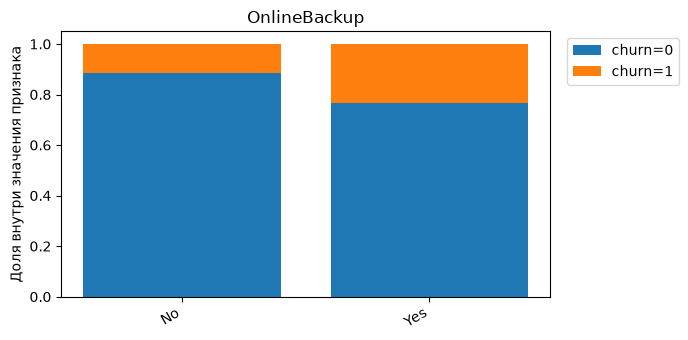

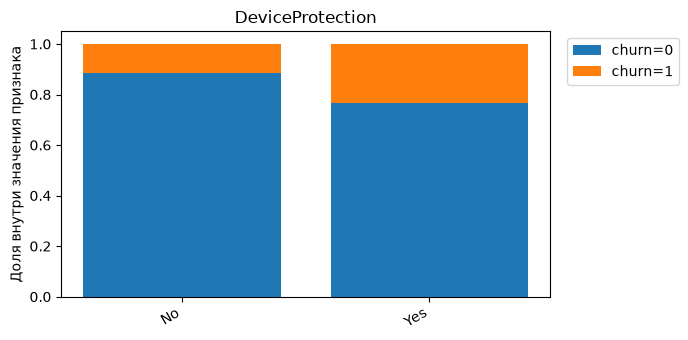

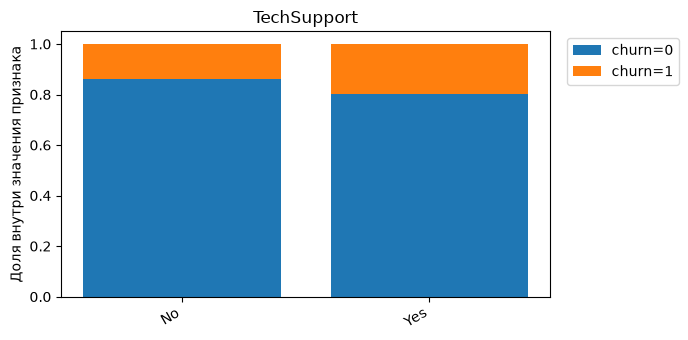

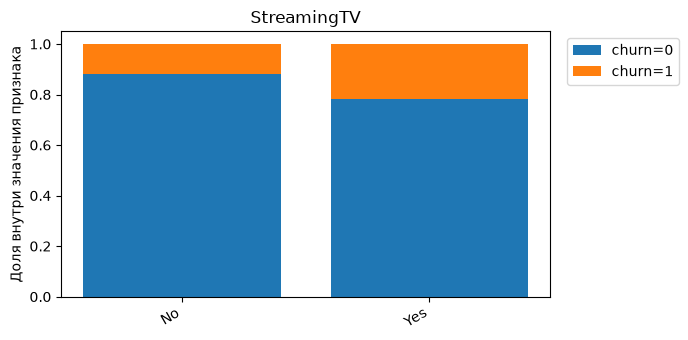

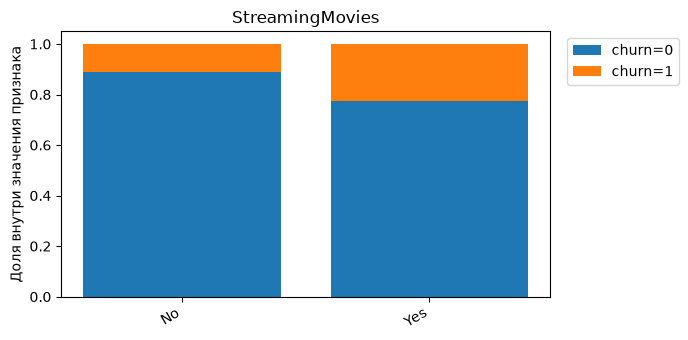

In [21]:
train_eda = X_train.copy()
train_eda['churn'] = y_train.values

categorical_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(train_eda[c])]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_eda[c])]

for col in categorical_cols:
    counts = train_eda.groupby([col, 'churn']).size().unstack(fill_value=0)
    props = counts.div(counts.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bottom = np.zeros(len(props))
    for c in sorted(props.columns):
        ax.bar(props.index.astype(str), props[c], bottom=bottom, label=f'churn={c}')
        bottom += props[c].values

    ax.set_ylabel('Доля внутри значения признака')
    ax.set_title(col)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

Для числовых признаков — распределение по группам `churn`.

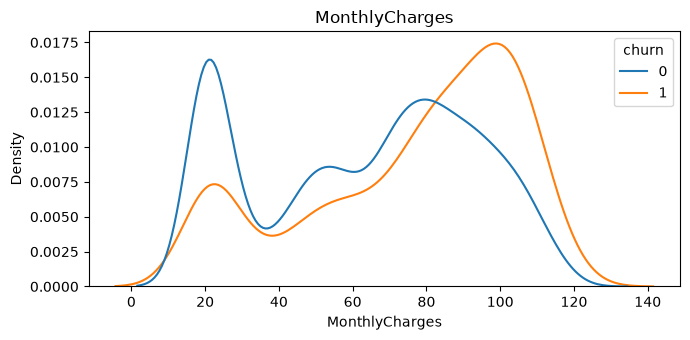

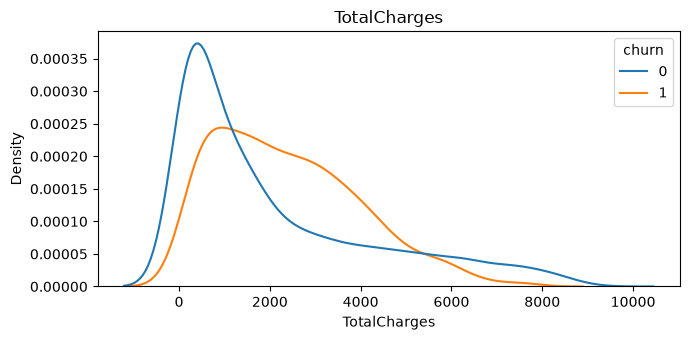

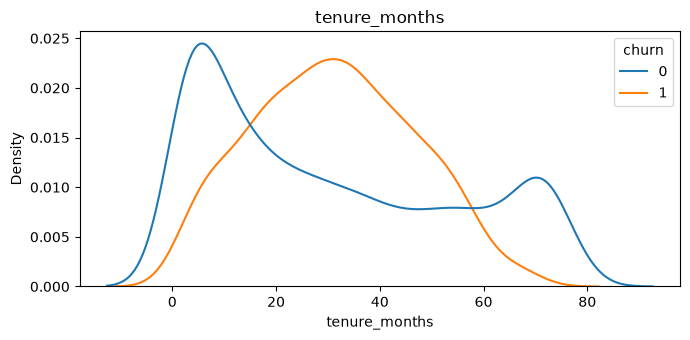

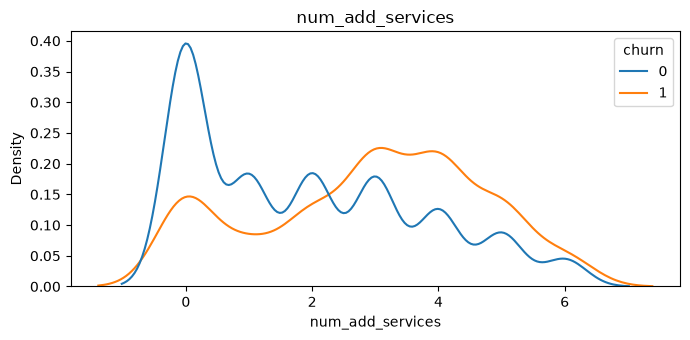

In [22]:
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.kdeplot(data=train_eda, x=col, hue='churn', common_norm=False, ax=ax)
    ax.set_title(col)
    plt.tight_layout()
    plt.show()

### Вывод

Сильнее всего с оттоком расходятся `Type` (месячные договоры уходят чаще годовых),
`tenure_months` (у ушедших он заметно ниже) и `PaymentMethod`. `gender` визуально
неразличим между группами — ожидаемо увидим это и в корреляционном анализе.

### Корреляционный анализ

Корреляции считаем только по `train`, чтобы отбор признаков не подсматривал в test.

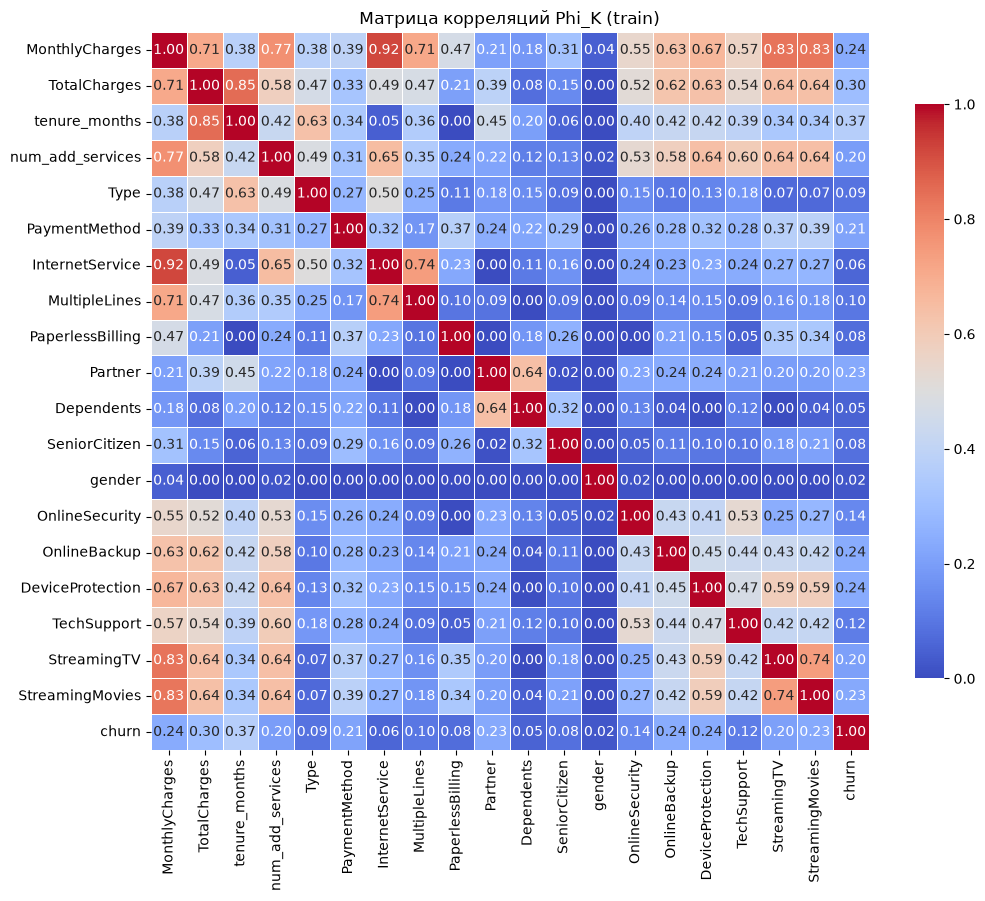

In [23]:
interval_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_months', 'num_add_services']
phik_matrix = train_eda.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(11, 9))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            cbar_kws={"shrink": .8}, linewidths=0.5)
plt.title('Матрица корреляций Phi_K (train)')
plt.tight_layout()
plt.show()

In [24]:
phik_matrix['churn'].sort_values(ascending=False)

churn               1.000000
tenure_months       0.367970
TotalCharges        0.298828
OnlineBackup        0.241456
MonthlyCharges      0.236810
DeviceProtection    0.236364
Partner             0.233562
StreamingMovies     0.232196
PaymentMethod       0.214324
StreamingTV         0.204509
num_add_services    0.198367
OnlineSecurity      0.142113
TechSupport         0.116355
MultipleLines       0.098448
Type                0.092025
SeniorCitizen       0.082870
PaperlessBilling    0.076058
InternetService     0.059291
Dependents          0.052942
gender              0.024942
Name: churn, dtype: float64

`gender` — единственный признак практически без связи с целевым: корреляция с `churn`
около 0.02. Остальные признаки решено оставить: модели на деревьях (а в сравнении
дальше побеждают именно они) не страдают от мультиколлинеарности между признаками услуг,
в отличие от линейных моделей — им это скорее на пользу, чем во вред.

In [25]:
feature_cols.remove('gender')
X_train = X_train.drop(columns='gender')
X_test = X_test.drop(columns='gender')

In [26]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_months', 'num_add_services']
cat_cols = [c for c in feature_cols if c not in num_cols]
len(num_cols), len(cat_cols)

(4, 14)

## Подготовка к обучению

Preprocessor для масштабирования числовых и кодирования категориальных признаков.

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Кроме моделей, добавим `DummyClassifier` — точку отсчёта. Без неё непонятно,
много ли 0.83 ROC-AUC или мало для этой задачи.

In [28]:
models_config = {
    'Dummy': {
        'model': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
        'params': {}
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 5, 10],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
        'params': {
            'classifier__n_estimators': [100, 200, 300, 500],
            'classifier__max_depth': [5, 10, 15, 20, None],
            'classifier__min_samples_split': [2, 5, 10, 20]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='auc',
            scale_pos_weight=len(y_train) / (2 * sum(y_train))
        ),
        'params': {
            'classifier__n_estimators': [100, 200, 300, 500],
            'classifier__max_depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
        'params': {
            'classifier__n_estimators': [100, 200, 300, 500],
            'classifier__max_depth': [-1, 5, 10, 15],
            'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced'),
        'params': {
            'classifier__iterations': [100, 200, 400, 600],
            'classifier__depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1]
        }
    }
}

## Обучение моделей

In [29]:
results = []
for name, cfg in models_config.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', cfg['model'])])

    if cfg['params']:
        search = RandomizedSearchCV(
            pipe, cfg['params'], n_iter=30, cv=cv, scoring='roc_auc',
            random_state=RANDOM_STATE, n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_est = search.best_estimator_
        cv_score = search.best_score_
        cv_std = search.cv_results_['std_test_score'][search.best_index_]
    else:
        pipe.fit(X_train, y_train)
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        best_est = pipe
        cv_score = scores.mean()
        cv_std = scores.std()

    results.append({'Model': name, 'CV_ROC_AUC': cv_score, 'CV_std': cv_std, 'Estimator': best_est})
    print(f"{name:20s} CV ROC-AUC = {cv_score:.4f} +/- {cv_std:.4f}")

Dummy                CV ROC-AUC = 0.4960 +/- 0.0130


D:\projects\portfolio\yandex-practicum-projects\telecom-churn-prediction\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 10 is smaller than n_iter=30. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


D:\projects\portfolio\yandex-practicum-projects\telecom-churn-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\projects\portfolio\yandex-practicum-projects\telecom-churn-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


LogisticRegression   CV ROC-AUC = 0.7690 +/- 0.0168


RandomForest         CV ROC-AUC = 0.8176 +/- 0.0175


XGBoost              CV ROC-AUC = 0.8311 +/- 0.0135


LightGBM             CV ROC-AUC = 0.8248 +/- 0.0128


CatBoost             CV ROC-AUC = 0.8301 +/- 0.0159


## Выбор модели

In [30]:
results_df = pd.DataFrame(results).sort_values('CV_ROC_AUC', ascending=False).reset_index(drop=True)
display(results_df[['Model', 'CV_ROC_AUC', 'CV_std']])

,Model,CV_ROC_AUC,CV_std
0,XGBoost,0.831081,0.013516
1,CatBoost,0.830082,0.015894
2,LightGBM,0.824807,0.012806
3,RandomForest,0.817616,0.017516
4,LogisticRegression,0.768984,0.016753
5,Dummy,0.495992,0.012975


In [31]:
best_model_name = results_df.iloc[0]['Model']
best_estimator = results_df.iloc[0]['Estimator']
print(f"Лучшая модель по CV: {best_model_name}")

Лучшая модель по CV: XGBoost


XGBoost и CatBoost расходятся меньше чем на одно стандартное отклонение —
их качество статистически неразличимо, но по чистому значению CV ROC-AUC впереди
XGBoost, его и берём для финальной проверки на тесте.

## Финальное предсказание

In [32]:
y_pred_proba = best_estimator.predict_proba(X_test)[:, 1]

final_roc = roc_auc_score(y_test, y_pred_proba)
final_acc = accuracy_score(y_test, (y_pred_proba > 0.5).astype(int))

print(f"ROC-AUC (тест): {final_roc:.4f}")
print(f"Accuracy (тест, порог 0.5): {final_acc:.4f}")

ROC-AUC (тест): 0.8244
Accuracy (тест, порог 0.5): 0.8126


Тестовый ROC-AUC ниже кросс-валидационного, как и должно быть — признаков, которые бы «подглядывали» в будущее, в модели больше нет.

### Матрица ошибок

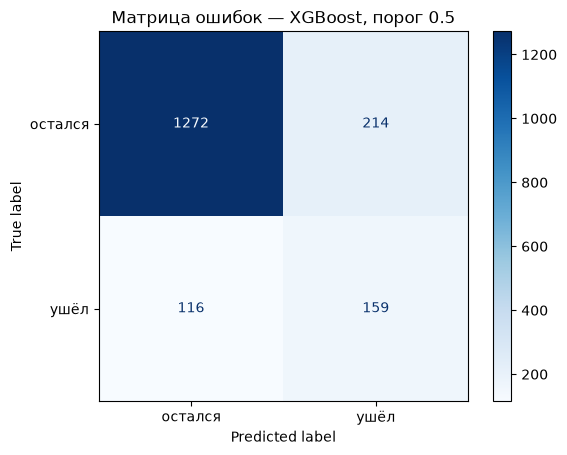

In [33]:
cm = confusion_matrix(y_test, (y_pred_proba > 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['остался', 'ушёл'])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Матрица ошибок — {best_model_name}, порог 0.5")
plt.show()

При пороге 0.5 часть уходящих клиентов (false negative) модель пропускает — это
цена того, что порог 0.5 выбран произвольно, а не под бизнес-задачу. Дальше подберём
порог осмысленно.

### Подбор порога

Задача — не классификация сама по себе, а отбор группы риска для точечных предложений.
Порог 0.5 для этого не обязан быть оптимальным: с ростом порога модель называет
группу риска меньше, но упускает больше реальных уходящих клиентов.

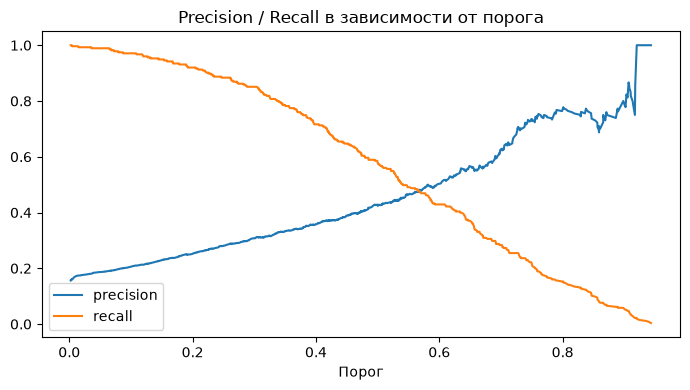

In [34]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 4))
plt.plot(thresholds, precision[:-1], label='precision')
plt.plot(thresholds, recall[:-1], label='recall')
plt.xlabel('Порог')
plt.legend()
plt.title('Precision / Recall в зависимости от порога')
plt.tight_layout()
plt.show()

In [35]:
rows = []
for thr in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    pred = (y_pred_proba >= thr).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    precision_v = tp / (tp + fp) if (tp + fp) else 0
    recall_v = tp / (tp + fn) if (tp + fn) else 0
    rows.append({
        'Порог': thr,
        'Доля базы в группе риска': pred.mean(),
        'Recall (доля пойманных уходящих)': recall_v,
        'Precision (точность отбора)': precision_v,
    })

pd.DataFrame(rows).style.format({
    'Доля базы в группе риска': '{:.1%}',
    'Recall (доля пойманных уходящих)': '{:.1%}',
    'Precision (точность отбора)': '{:.1%}',
})

,Порог,Доля базы в группе риска,Recall (доля пойманных уходящих),Precision (точность отбора)
0,0.300000,43.2%,85.1%,30.7%
1,0.350000,36.7%,78.5%,33.4%
2,0.400000,31.3%,71.6%,35.8%
3,0.450000,26.0%,64.7%,38.9%
4,0.500000,21.2%,57.8%,42.6%
5,0.550000,16.5%,49.1%,46.6%
6,0.600000,13.3%,42.9%,50.4%
7,0.650000,10.2%,36.7%,56.4%
8,0.700000,7.0%,28.4%,62.9%


При базовом уровне оттока около 16% случайное таргетирование 37% базы поймало бы
только 37% уходящих. Модель на пороге 0.35 при том же охвате базы (37%) ловит около 78%
уходящих — более чем двукратный выигрыш относительно случайного отбора. Порог
можно двигать в зависимости от того, на скольких клиентов хватает бюджета на промокоды:
выше порог — меньше ложных срабатываний, но больше пропущенных уходящих.

### Важность признаков

Встроенная важность бустинга считается по колонкам после one-hot-encoding — вклад
одного категориального признака размазывается по нескольким бинарным столбцам.
Возьмём permutation importance: она считается по исходным колонкам и не зависит от
кодирования.

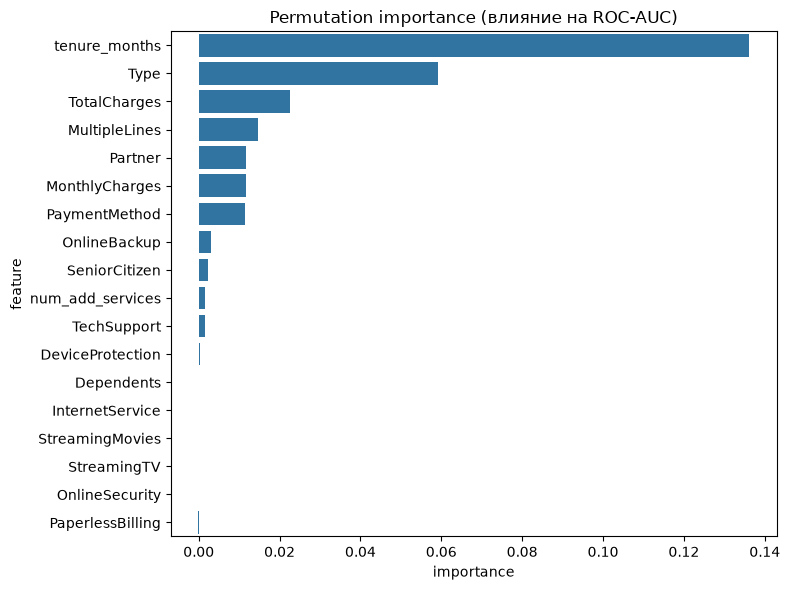

,feature,importance,std
0,tenure_months,0.136219,0.015840
1,Type,0.059255,0.003842
2,TotalCharges,0.022467,0.003964
3,MultipleLines,0.014655,0.003515
4,Partner,0.011714,0.001964
5,MonthlyCharges,0.011655,0.004375
6,PaymentMethod,0.011400,0.004347
7,OnlineBackup,0.003123,0.001874
8,SeniorCitizen,0.002178,0.001150
9,num_add_services,0.001668,0.002694


In [36]:
perm = permutation_importance(
    best_estimator, X_test, y_test, scoring='roc_auc',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Permutation importance (влияние на ROC-AUC)')
plt.tight_layout()
plt.show()

importance_df.head(10)

Сильнее всего на предсказание влияют `tenure_months` (длительность обслуживания),
`Type` (тип договора) и `TotalCharges`. Это совпадает со здравым смыслом: новые
клиенты на месячных договорах — основная группа риска, а долгосрочные абоненты
на годовых контрактах уходят редко.

## Выводы

В ходе проекта построена модель предсказания оттока клиентов оператора «ТелеДом».
Лучший результат показал XGBoost: ROC-AUC 0.83 на кросс-валидации и 0.82 на
тестовой выборке (статистически неотличимо от CatBoost, который занял второе место),
при том что модель без обучения (DummyClassifier) даёт лишь 0.50.

Наиболее значимые признаки — длительность обслуживания, тип договора и накопленные
платежи. Модель на пороге 0.35 при отборе 37% базы в группу риска
ловит около 78% реально уходящих клиентов — более чем двукратный выигрыш относительно
случайного отбора того же объёма.

**Бизнес-рекомендации:**
- Использовать модель для приоритизации базы при рассылке промокодов, ориентируясь на порог по доступному бюджету, а не на 0.5 по умолчанию.
- Обратить особое внимание на новых клиентов с месячным договором — это основная группа риска.
- Дособрать данные об обращениях в техподдержку и причинах ухода — сейчас модель работает только с тарифом и составом услуг.

## Что бы сделал иначе

Первая версия признака длительности обслуживания считалась напрямую от дат
(`BeginDate`/`EndDate` относительно даты среза) и давала ROC-AUC 0.90 на
кросс-валидации и 0.92 на тесте — тест выше CV, что для 5-фолдовой кросс-валидации
само по себе подозрительно.

Проверил гипотезу контролируемым экспериментом: обучил одну и ту же модель на одном
и том же разбиении, меняя только гранулярность признака tenure. Оказалось, дело не в
том, что признак вообще посчитан от дат, а в том, что он был посчитан **в днях**, а не
в месяцах:

| Признак tenure | CV ROC-AUC | Test ROC-AUC |
|---|---|---|
| из дат, в днях (исходный вариант) | 0.90 | 0.92 |
| из дат, округлённый до месяцев | 0.83 | 0.83 |
| из платежей, `TotalCharges / MonthlyCharges` (использовано в этой версии) | 0.83 | 0.83 |

Округление до месяцев снижает метрику и на кросс-валидации, и на тесте одновременно —
будь дело в переобучении на шуме, страдал бы только тест. Похоже, точный день начала
и окончания договора в этом синтетическом датасете статистически связан с оттоком не
через содержательный сигнал «сколько человек уже пользуется услугой», а через артефакт
того, как вообще генерировались даты в датасете. Не нашёл способа сформулировать
бизнес-объяснение, почему разница в один-два дня должна поднимать ROC-AUC на 7 п.п. —
поэтому предпочёл более скромную, но объяснимую метрику 0.83 вместо эффектной, но
подозрительной 0.92.

Если бы делал заново — сразу проверял бы чувствительность метрики к гранулярности
любого признака, построенного из дат, а не только к его смысловому содержанию.